# Review Existing Keyword Extraction Workflow
This section reviews the workflow from the Indian Express extraction notebooks. The process involves:
- Loading GT keywords and HTML content for each page
- Processing keywords using stemming and stopword filtering
- Extracting keywords from HTML tags
- Scoring keywords based on tag weights and frequency
- Calculating precision, recall, and F1-score
- Visualizing performance metrics across pages

# Analyze Core Functions and Logic
The main functions in the Indian Express workflow are:
- `process_keywords`: Cleans, stems, and filters stopwords from a list of keywords.
- `extract_and_process_keywords_from_tag`: Extracts keywords from specified HTML tags and processes them.
- Aggregation logic: Scores keywords based on tag weights and frequency, then calculates precision, recall, and F1-score for extracted keywords.

# Set Up Configuration for Herald Directory
Configure dataset parameters for the herald directory:
- Set dataset name to "herald"
- Specify dataset language (e.g., English)
- Define base URL and number of pages
- Prepare tag rating set for scoring

In [10]:
# Configuration for Herald

dataset_name = "herald"
# url_gt = "GT.txt"
# url = "ULR.txt"
dataset_language = "english"
base_url = f"https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/{dataset_name}"
num_pages = 200

# Stemming and Stopword Libraries (English)
from nltk.stem.snowball import SnowballStemmer
import nltk
from nltk.corpus import stopwords  # Stopword library

# Initialize stemmer and stopwords for English
stemmer = SnowballStemmer(dataset_language)
nltk.download('stopwords')
nltk_english_stopwords = set(stopwords.words(dataset_language))

# Tag rating set (example values, adjust as needed)
{
    "URL": 69.5116,
    "h1": 54.3161,
    "head": 39.1021,
    "title": 39.1021,
    "figcaption": 30.7214,
    "figure": 30.7214,
    "article": 14.9774,
}

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'URL': 69.5116,
 'h1': 54.3161,
 'head': 39.1021,
 'title': 39.1021,
 'figcaption': 30.7214,
 'figure': 30.7214,
 'article': 14.9774}

# Implement Keyword Processing Functionality for Herald
Define a function to clean, stem, and filter stopwords from a list of keywords for the herald dataset.

In [11]:
import re

def process_keywords(keywords):
    """Apply cleaning, stemming, and stopword filtering to a list of keywords. Returns a processed list of useful words."""
    processed = []
    for word in keywords:
        # Clean word: keep only alphabetic characters
        cleaned_word = re.sub(r'[^a-zA-Z]', '', word)
        if not cleaned_word:
            continue
        # Stem word
        stemmed_word = stemmer.stem(cleaned_word.lower())
        # Filter stopwords
        if stemmed_word not in nltk_english_stopwords:
            processed.append(stemmed_word)
    # Return unique processed keywords (useful words only)
    return processed

# Extract and Process Keywords from Herald HTML Tags
Define a function to extract keywords from specified HTML tags in herald files, process them, and calculate keyword frequencies.

In [12]:
from bs4 import BeautifulSoup

def extract_and_process_keywords_from_tag(html_text, tag_name):
    """Extracts keywords from the content inside the specified tag in the given HTML text, processes them using process_keywords, and returns a dictionary with keyword frequencies."""
    soup = BeautifulSoup(html_text, 'html.parser')
    elements = soup.find_all(tag_name)
    raw_keywords = []
    for elem in elements:
        text = elem.get_text(separator=' ')
        raw_keywords.extend(text.split())
    processed = process_keywords(raw_keywords)
    freq = {}
    for kw in processed:
        freq[kw] = freq.get(kw, 0) + 1
    return freq

# Aggregate and Visualize Keyword Extraction Metrics for Herald
Aggregate precision, recall, and F1-score metrics for keyword extraction in herald, and visualize the results using plots.

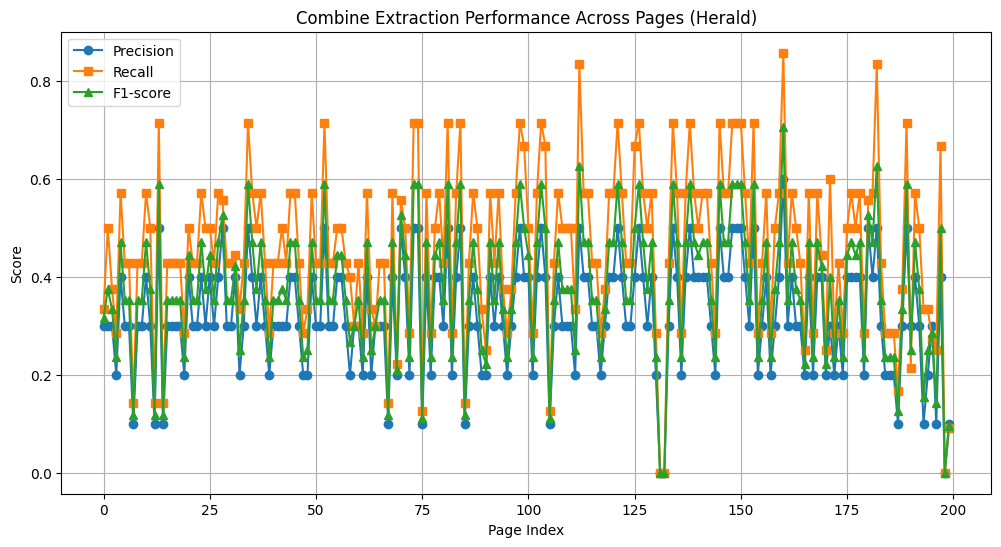


Average Precision: 0.3230
Average Recall: 0.4602
Average F1-score: 0.3783


In [13]:
from urllib.parse import urlparse, unquote
from collections import defaultdict
import urllib.request
import matplotlib.pyplot as plt

frequency_weight = 10

dataset_precisions = []
dataset_recalls = []
dataset_f1s = []

for i in range(num_pages):
    gt_url = f"{base_url}/{i}/GT.txt"
    web_page_url = f"{base_url}/{i}"
    url_file_url = f"{base_url}/{i}/URL.txt"
    processed_gt_keywords = []
    extracting_keywords = {}
    headers = {"User-Agent": "Mozilla/5.0 (compatible; Copilot/1.0)"}
    gt_req = urllib.request.Request(gt_url, headers=headers)
    web_req = urllib.request.Request(web_page_url, headers=headers)
    url_req = urllib.request.Request(url_file_url, headers=headers)
    try:
        with urllib.request.urlopen(gt_req, timeout=5) as response:
            gt_text = response.read().decode("utf-8-sig").strip()
            gt_keywords = gt_text.split()
            processed_gt_keywords = list(set(process_keywords(gt_keywords)))
    except Exception as e:
        continue
    # HTML tag ratings
    try:
        with urllib.request.urlopen(web_req, timeout=5) as web_response:
            html_text = web_response.read().decode("utf-8-sig").strip()
            for tag, rating in tag_rating_set.items():
                result = extract_and_process_keywords_from_tag(html_text, tag)
                for kw, freq in result.items():
                    value = rating + freq * frequency_weight
                    if kw in extracting_keywords:
                        extracting_keywords[kw] += value
                    else:
                        extracting_keywords[kw] = value
    except Exception as e:
        continue
    # URL rating as a pseudo-tag
    try:
        with urllib.request.urlopen(url_req, timeout=5) as url_response:
            real_url = url_response.read().decode("utf-8-sig").strip()
            parsed_url = urlparse(real_url)
            normalized_path = unquote(parsed_url.path.lower())
            url_tokens = re.findall(r"[a-zåäöA-ZÅÄÖ0-9]+", normalized_path)
            processed_url_keywords = process_keywords(url_tokens)
            url_rating = tag_rating_set.get('URL', 0)
            for kw in processed_url_keywords:
                value = url_rating
                if kw in extracting_keywords:
                    extracting_keywords[kw] += value
                else:
                    extracting_keywords[kw] = value
    except Exception as e:
        continue
    # Calculate Precision, Recall, and F1-score
    top_10 = sorted(extracting_keywords.items(), key=lambda x: x[1], reverse=True)[:10]
    extracted_keywords = set([kw for kw, _ in top_10])
    gt_keywords_set = set(processed_gt_keywords)
    true_positives = len(extracted_keywords & gt_keywords_set)
    precision = true_positives / len(extracted_keywords) if len(extracted_keywords) > 0 else 0
    recall = true_positives / len(gt_keywords_set) if len(gt_keywords_set) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    dataset_precisions.append(precision)
    dataset_recalls.append(recall)
    dataset_f1s.append(f1_score)

plt.figure(figsize=(12, 6))
plt.plot(dataset_precisions, label='Precision', marker='o')
plt.plot(dataset_recalls, label='Recall', marker='s')
plt.plot(dataset_f1s, label='F1-score', marker='^')
plt.xlabel('Page Index')
plt.ylabel('Score')
plt.title('Combine Extraction Performance Across Pages (Herald)')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAverage Precision: {sum(dataset_precisions)/len(dataset_precisions):.4f}")
print(f"Average Recall: {sum(dataset_recalls)/len(dataset_recalls):.4f}")
print(f"Average F1-score: {sum(dataset_f1s)/len(dataset_f1s):.4f}")